# Relaciones entre variables

In [28]:
from proyecto_ciencia_de_datos.config import PROCESSED_DATA_DIR
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

axa_df = pd.read_csv(PROCESSED_DATA_DIR / 'axa_EDA_son.csv', sep=',', header='infer', low_memory=False)
inegi_df = pd.read_csv(PROCESSED_DATA_DIR / 'inegi_EDA_son.csv', sep=',', header='infer')
weather_df = pd.read_csv(PROCESSED_DATA_DIR / 'weather_EDA_son.csv', sep=',', header='infer')

## AXA

Una matriz de correlacion para visualizar los valores numericos del dataset

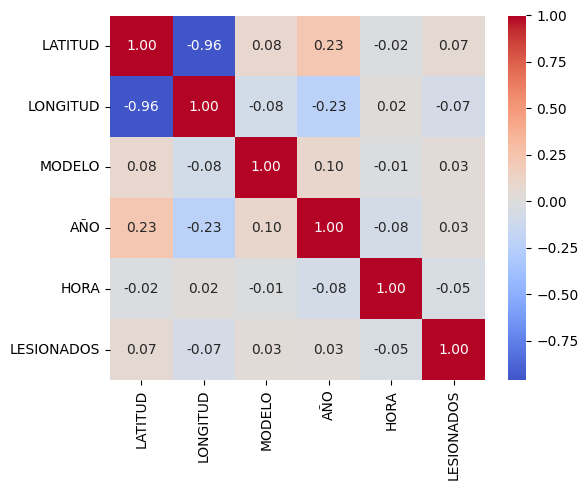

In [10]:
# Create correlation matrix for numerical columns
corr = axa_df[['LATITUD','LONGITUD','MODELO','AÑO','HORA','LESIONADOS']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.tight_layout()
plt.show()

### Visualizacion para las variables categoricas
#### Usando Heatmaps

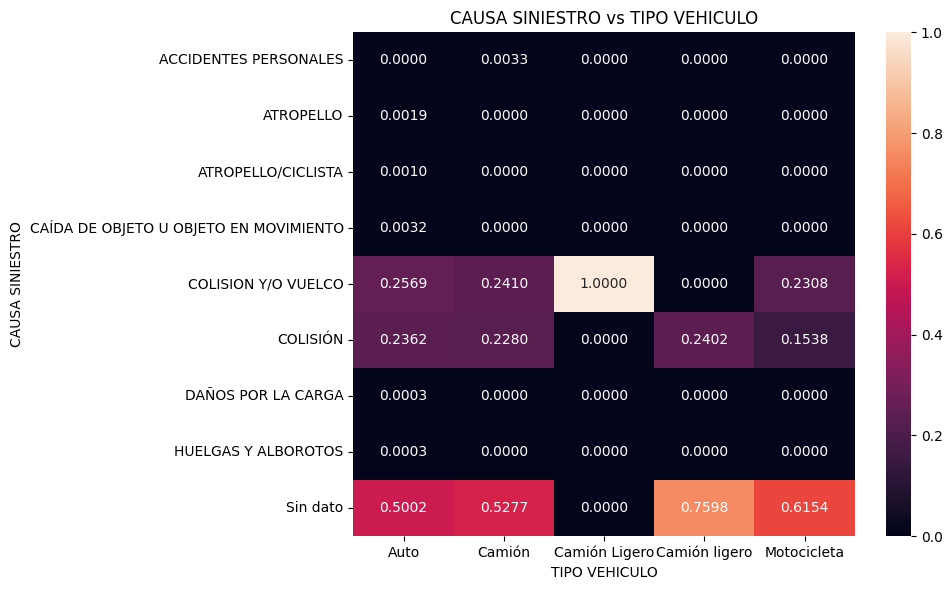

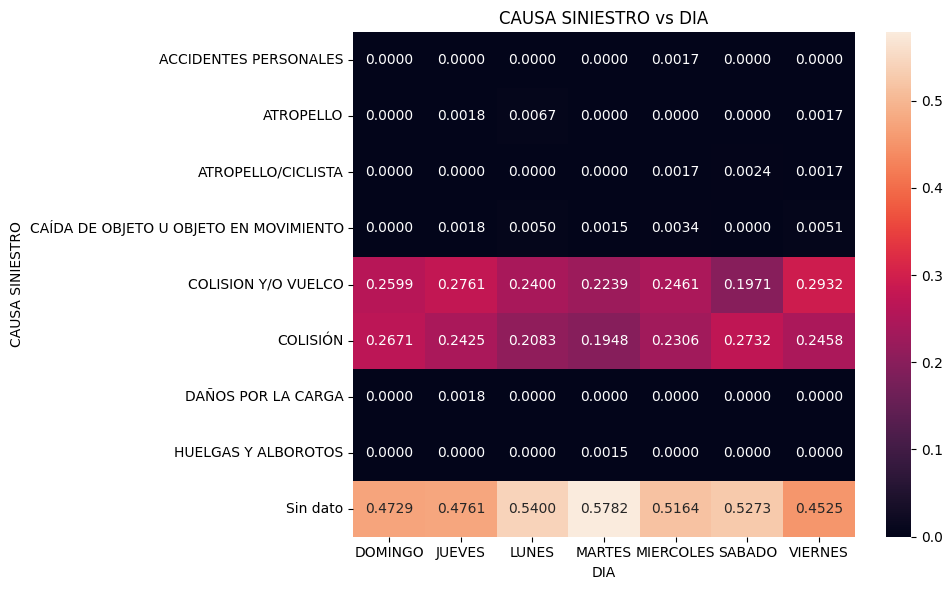

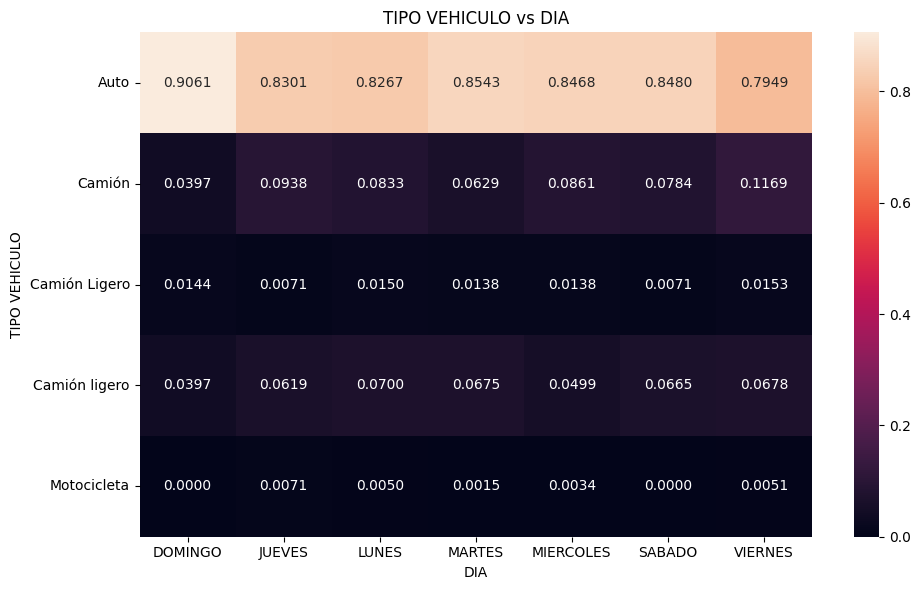

In [11]:
# Lista de columnas categóricas
cat_cols = ['CAUSA SINIESTRO', 'TIPO VEHICULO', 'DIA']
# Ciudad excluida por que no se ve bien en este tipo de grafico

# Generar combinaciones de dos columnas categóricas
pairs = []
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        pairs.append((cat_cols[i], cat_cols[j]))

# Heatmaps
for col1, col2 in pairs:
    plt.figure(figsize=(10, 6))

    # Tabla de contingencia con categorías completas
    ct = pd.crosstab(
        axa_df[col1],
        axa_df[col2],
        dropna=False,
        normalize='columns'   # Normaliza por fila
    )

    sns.heatmap(ct, annot=True, fmt=".4f")
    plt.title(f"{col1} vs {col2}")
    plt.tight_layout()
    plt.show()


OBSERVACIONES:

Podemos observar que:
- Los accidentes más comunes en los datos de AXA son causados por **autos** personales (Por que tienen la mayor cantidad de conductores)
- El día con más accidentes es el **Martes**
- Los accidentes más comunes son **Colisión** y **Colisión Y/O Vuelco** (Excluyendo 'Sin Dato')

La mayoria de correlaciones son hacia los Autos, que pasa si vemos la correlacion sin ellos?

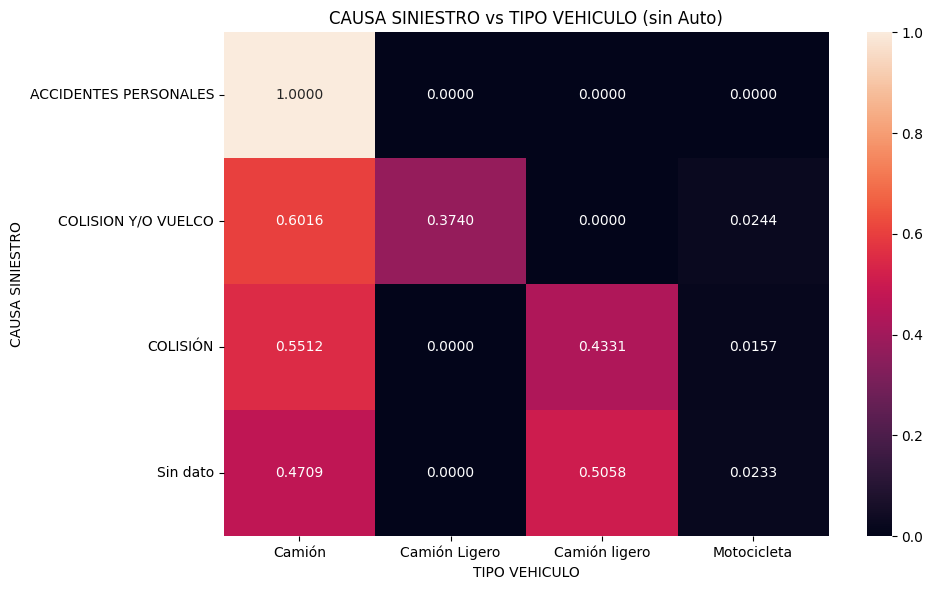

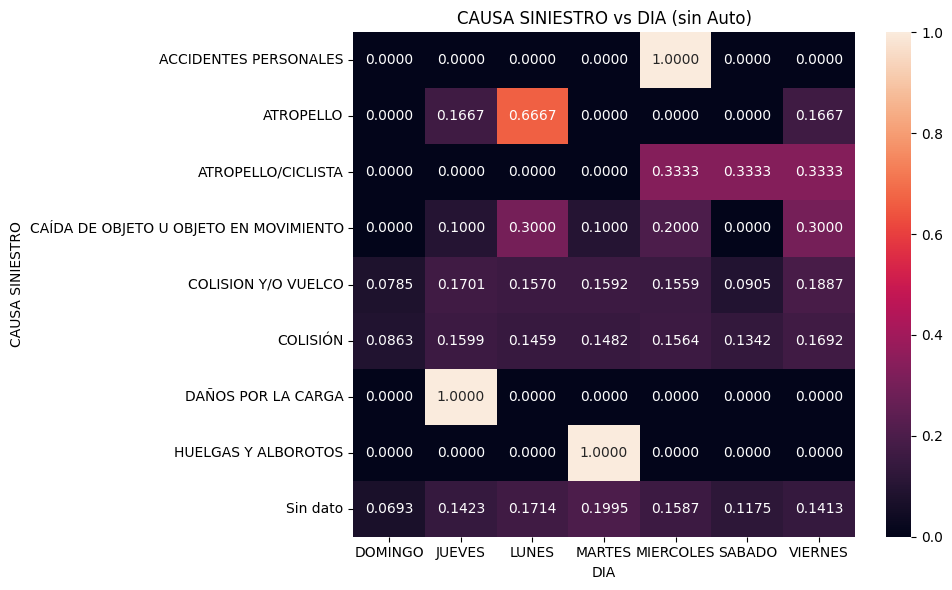

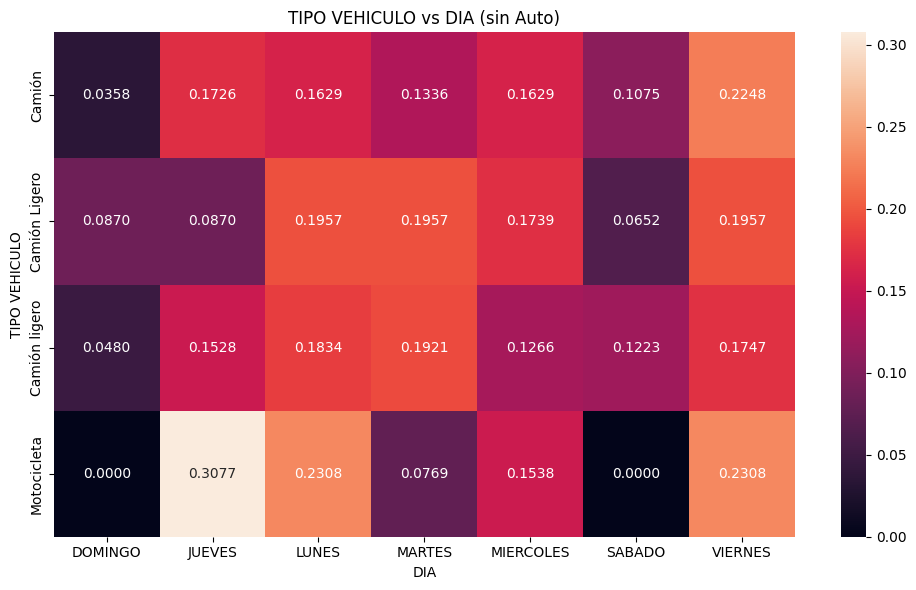

In [12]:
cat_cols = ['CAUSA SINIESTRO', 'TIPO VEHICULO', 'DIA']

# Generar pares
pairs = []
for i in range(len(cat_cols)):
    for j in range(i+1, len(cat_cols)):
        pairs.append((cat_cols[i], cat_cols[j]))

for col1, col2 in pairs:
    # Copia filtrada solo para la gráfica actual
    df_plot = axa_df.copy()

    # Excluir "Auto" cuando TIPO VEHICULO aparece en cualquiera de las dos columnas
    if col1 == 'TIPO VEHICULO' or col2 == 'TIPO VEHICULO':
        df_plot = df_plot[df_plot['TIPO VEHICULO'] != 'Auto']

    # Tabla normalizada por fila
    ct = pd.crosstab(
        df_plot[col1],
        df_plot[col2],
        dropna=False,
        normalize='index'
    )

    # Eliminar filas/columnas de Auto si quedaron en el índice accidentalmente
    if 'Auto' in ct.index:
        ct = ct.drop(index='Auto')
    if 'Auto' in ct.columns:
        ct = ct.drop(columns='Auto')
        

    # Graficar
    plt.figure(figsize=(10, 6))
    sns.heatmap(ct, annot=True, fmt=".4f")
    plt.title(f"{col1} vs {col2} (sin Auto)")
    plt.tight_layout()
    plt.show()


OBSERVACIONES
Al haber eliminado los autos personales de la grafica, podemos notar nuevas relaciones:

- Los accidentes más comunes en los datos de AXA son causados por *Camiones*
- Ahora ya no hay un día con más accidentes, ya que ahora se distribuye los dias con accidentes en una forma más general 
- Los accidentes más comunes ya no son **Colisión** y **Colisión Y/O Vuelco** pero ahora la cantidad de **'Sin Dato'** se reducío considerablemente, lo cual significa que la mayoria de estos son por **autos** personales
- Los accidentes **Personales** parecen ser causados solamente por **Camión** y solo el **Miercoles**, esto puede ser por que no muchos accidentes son marcados como **Personales** o son registrados como **'Sin Dato'**

## INEGI

Primero una grafica de correlación para observar si hay alguna relación obvia entre las variables categoricas:

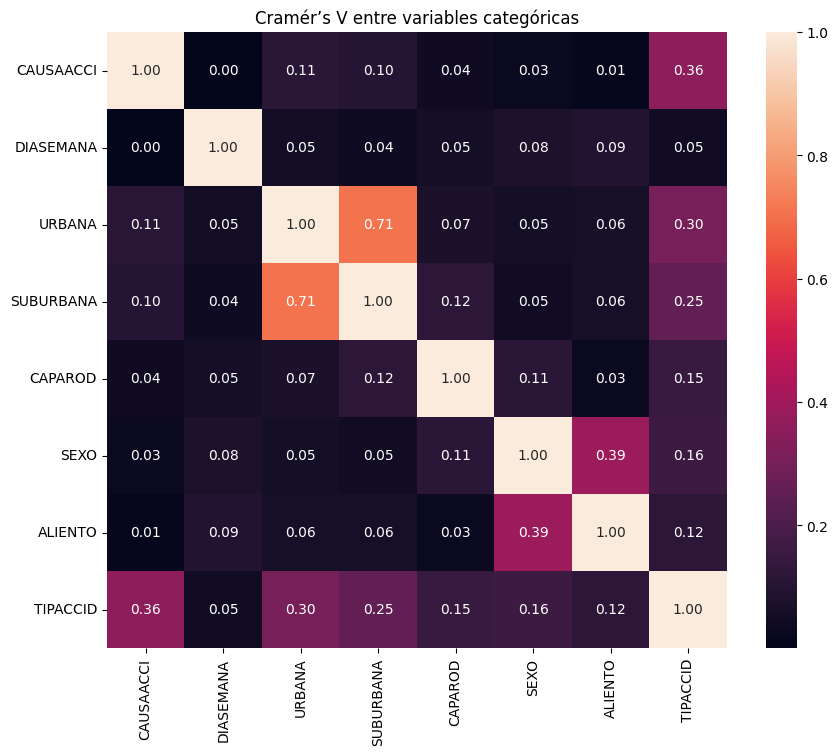

In [13]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    phi2 = chi2 / n
    r, k = ct.shape
    phi2_corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    r_corr = r - ((r-1)**2)/(n-1)
    k_corr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2_corr / min((k_corr-1),(r_corr-1)))

cats = ['CAUSAACCI','DIASEMANA','URBANA','SUBURBANA','CAPAROD','SEXO','ALIENTO', 'TIPACCID']

mat = pd.DataFrame(index=cats, columns=cats, dtype=float)

for c1 in cats:
    for c2 in cats:
        mat.loc[c1,c2] = cramers_v(inegi_df[c1], inegi_df[c2])

plt.figure(figsize=(10,8))
sns.heatmap(mat, annot=True, fmt=".2f")
plt.title("Cramér’s V entre variables categóricas")
plt.show()


Parece haber algunas relaciones entre la categoria **Suburbana** con **Urbana** y **Sexo** con **Aliento**, además de que el tipo de accidente tiene mucha relación con todas las variables, habra que ver las relaciones de las categorias más a fondo.

### Observando relaciones con tipo de accidente
#### Utilizando Heatmaps

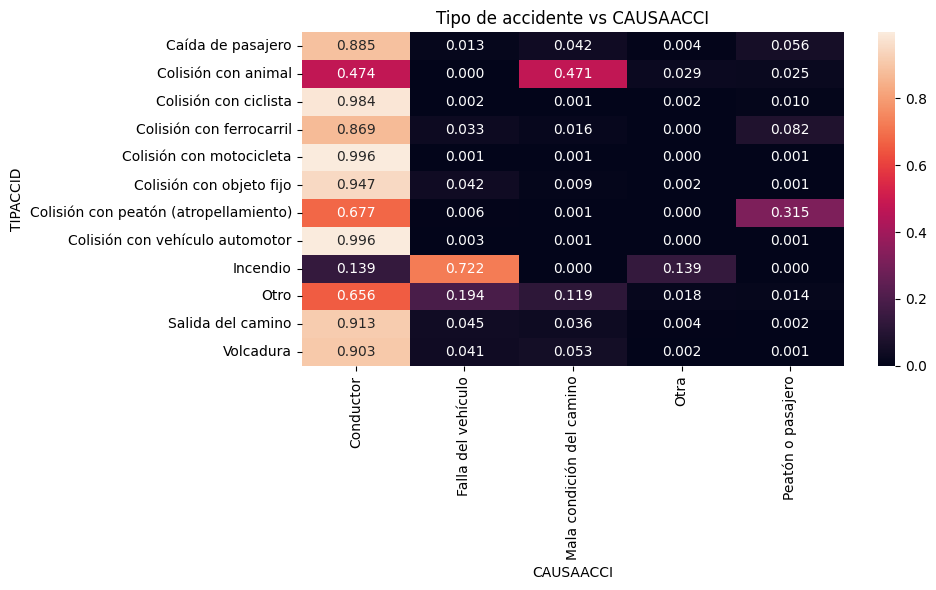

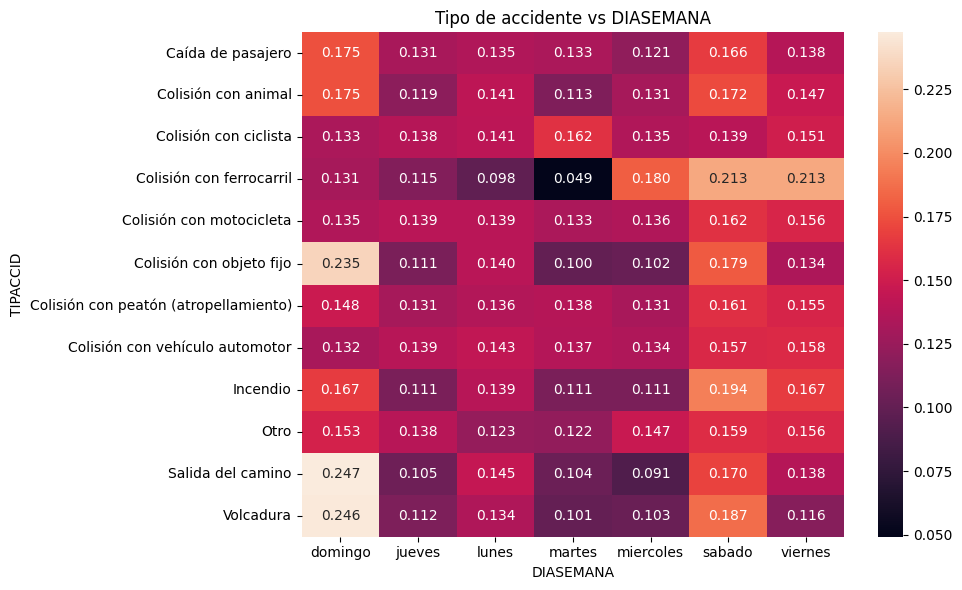

In [14]:
# Columnas categóricas importantes
cat_cols = [
    'CAUSAACCI',
    'DIASEMANA'
]

# Heatmaps
for col in cat_cols:

    ct = pd.crosstab(
        inegi_df['TIPACCID'],
        inegi_df[col],
        dropna=True,
        normalize='index'
    )

    plt.figure(figsize=(10, 6))
    sns.heatmap(ct, annot=True, fmt=".3f")
    plt.title(f"Tipo de accidente vs {col}")
    plt.tight_layout()
    plt.show()


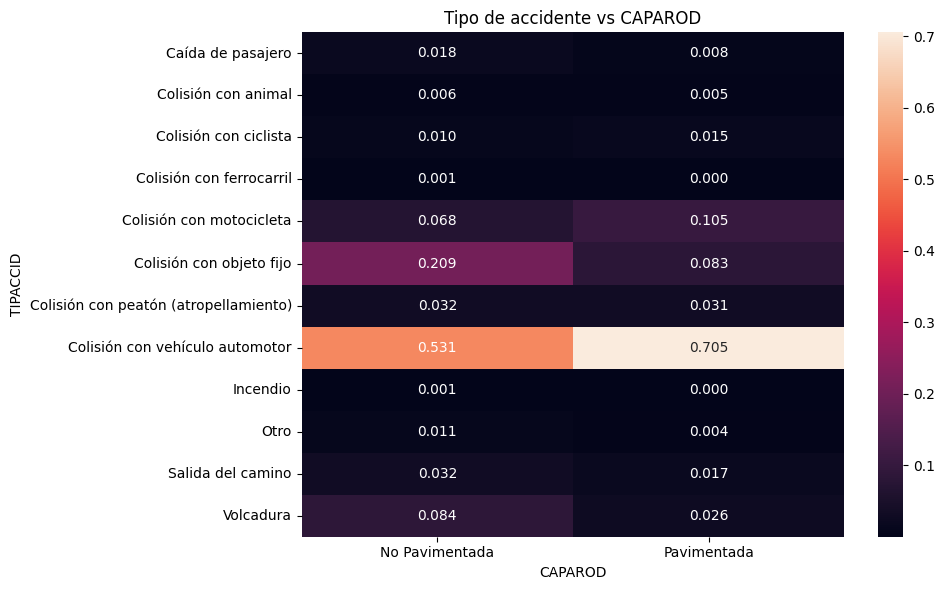

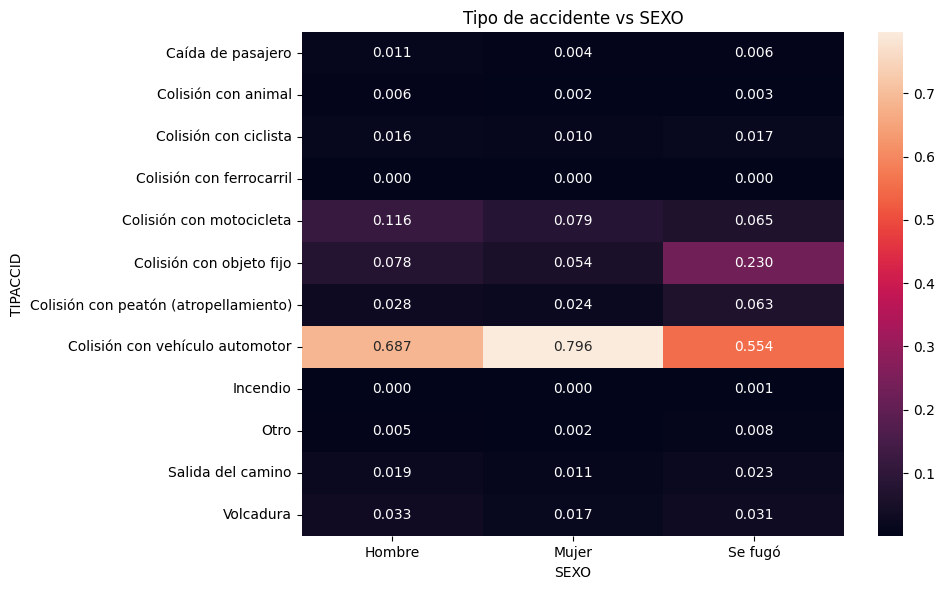

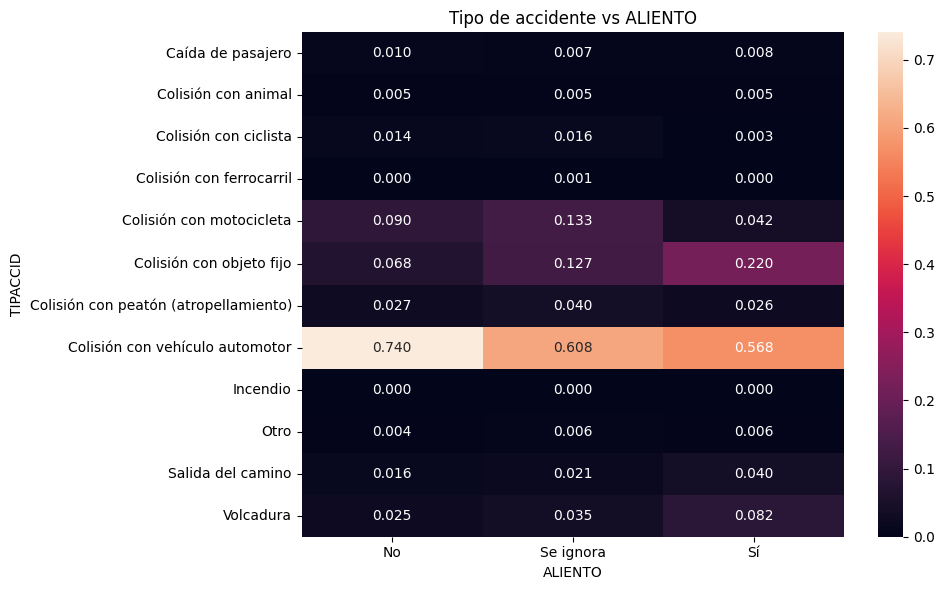

In [15]:
cat_cols2 = [
    'CAPAROD',
    'SEXO',
    'ALIENTO'
]
# Heatmaps
for col in cat_cols2:

    ct = pd.crosstab(
        inegi_df['TIPACCID'],
        inegi_df[col],
        dropna=True,
        normalize='columns'
    )

    plt.figure(figsize=(10, 6))
    sns.heatmap(ct, annot=True, fmt=".3f")
    plt.title(f"Tipo de accidente vs {col}")
    plt.tight_layout()
    plt.show()


In [16]:
inegi_df['CAPAROD'].value_counts()

CAPAROD
Pavimentada       133451
No Pavimentada      9190
Name: count, dtype: int64

In [17]:
inegi_df['SEXO'].value_counts()

SEXO
Hombre     95373
Mujer      30157
Se fugó    17111
Name: count, dtype: int64

In [18]:
inegi_df['ALIENTO'].value_counts() 

ALIENTO
No           93920
Se ignora    45173
Sí            3548
Name: count, dtype: int64

#### Observaciones del tipo de accidente:

- Causa de Accidente:
    - La mayoria de accidentes son por culpa del conductor, excepto:
        - **Incendios**, los cuales son por falla del vehiculo
        - **Colision con Animal**, los cuales son en parte por la mala condición del camino
        - **Atropellamiento**, los cuales son en parte por que un **pasajero o peaton** que distraen al conductor
- Dia de la Semana:
    - El martes tiene la menor cantidad de accidentes con **ferrocarriles** pero viernes y sabado tienen más que el resto de días
    - El domingo especificamente tiene una mayor cantidad de accidentes de tipo:
        - Colisión con objeto fijo
        - Salida del camino
        - Volcadura

Algunas variables no se lograban apreciar las diferencias, asi que las normalizamos con base a la columna en lugar del accidente:

- Calle Pavimentada:
    - La mayoria sucede en pavimentada pero esto es por la proporcion de accidentes en cada tipo
    - La colisión con objetos fijos sucede mayoritariamente en calles no pavimentadas
    - Las volcaduras son más comunes en calles no pavimentadas

- Sexo:
    - Los accidentes más comunes para los 2 sexos y los que se fugan es **Colisión con Vehiculo Automotor**
        - Las mujeres tienen una mayor proporción de este tipo de accidente comparado a los hombres y que se fugan
    - Cuando es **Colisión con Objeto Fijo** es más probable que se fuge el culpable
    - Los hombres tienen más colisiones con **Motocicleta**
    
- Aliento:
    - La gran mayoria de accidentes son causados por gente sin aliento alcoholico o se ignora por completo
    - Cuando es **Colisión con Objeto Fijo** es más probable que tengan aliento alcoholico

### Observando relaciones con causa de accidente
#### Utilizando Heatmaps


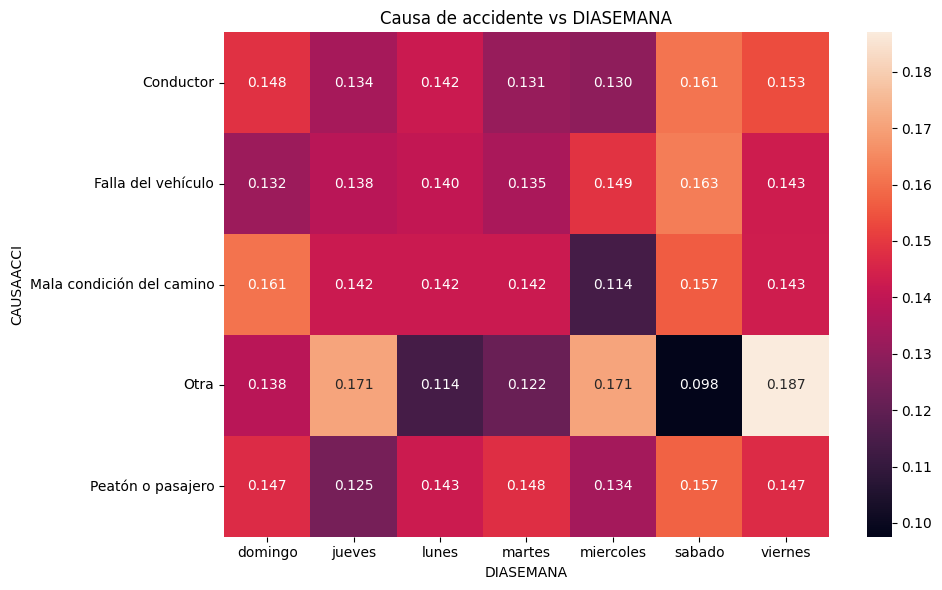

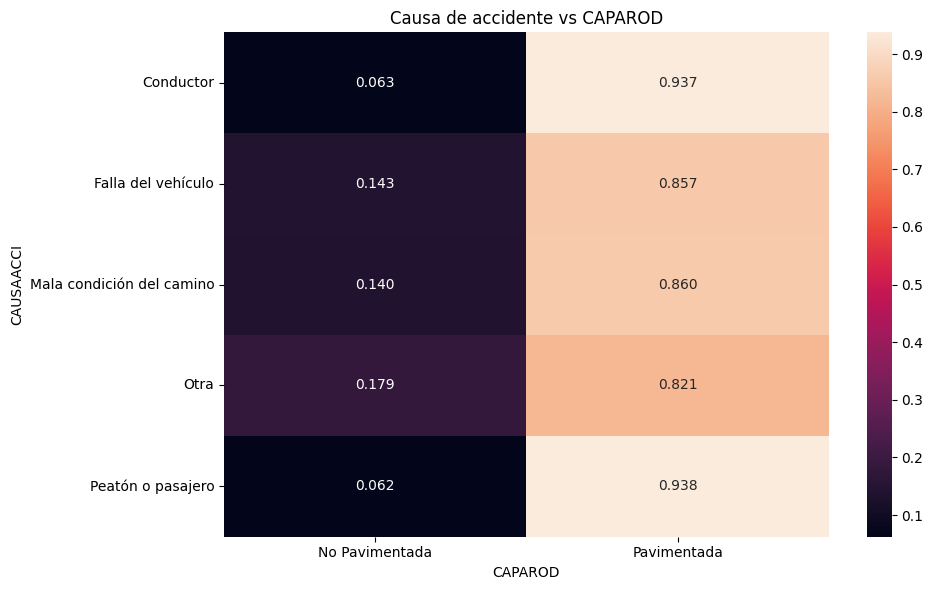

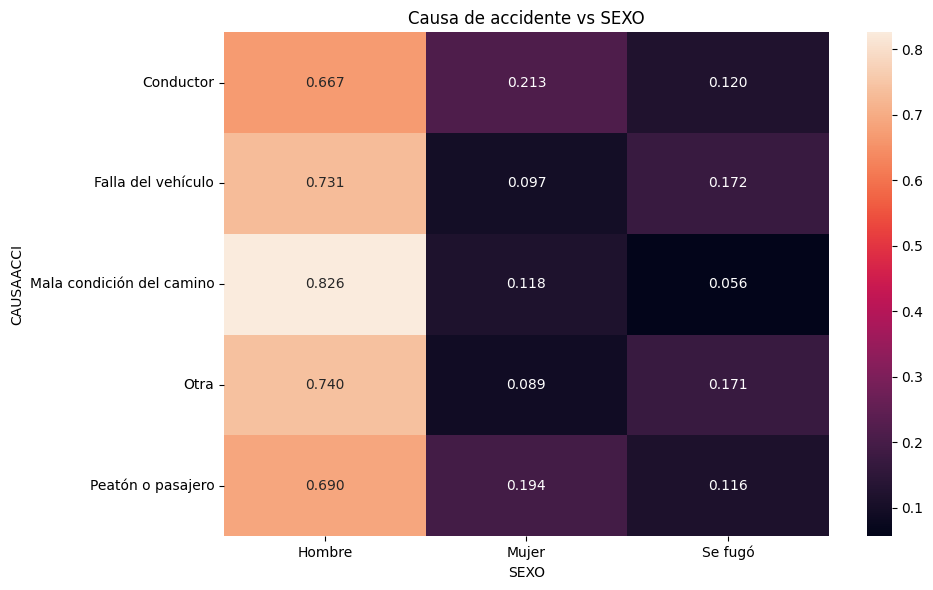

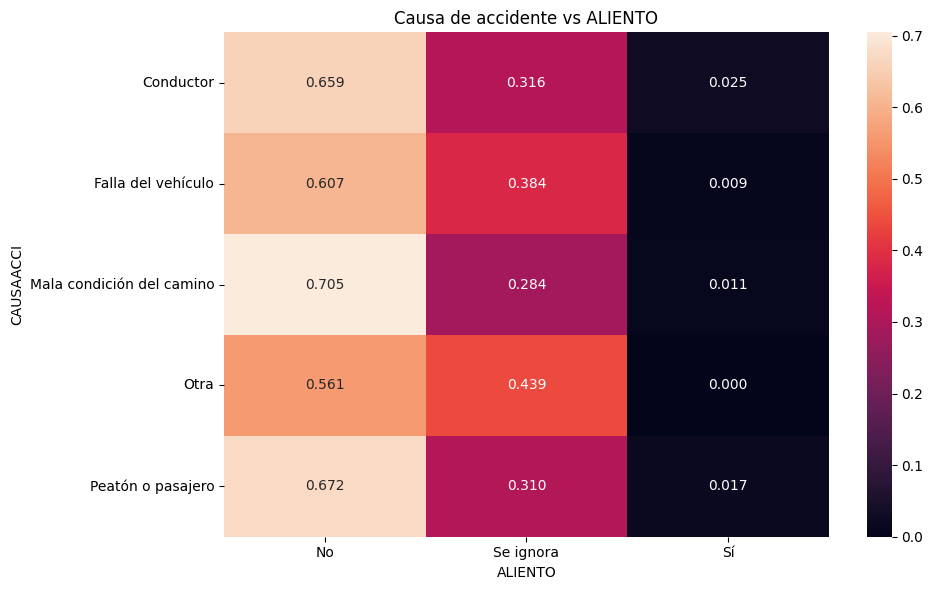

In [19]:
# Columnas categóricas importantes
cat_cols3 = [
    'DIASEMANA',
    'CAPAROD',
    'SEXO',
    'ALIENTO'
]

# Heatmaps
for col in cat_cols3:

    ct = pd.crosstab(
        inegi_df['CAUSAACCI'],
        inegi_df[col],
        dropna=True,
        normalize='index'
    )

    plt.figure(figsize=(10, 6))
    sns.heatmap(ct, annot=True, fmt=".3f")
    plt.title(f"Causa de accidente vs {col}")
    plt.tight_layout()
    plt.show()


In [20]:
inegi_df['CAUSAACCI'].value_counts()

CAUSAACCI
Conductor                    138601
Peatón o pasajero              1620
Falla del vehículo             1339
Mala condición del camino       958
Otra                            123
Name: count, dtype: int64

#### Observaciones de la causa de accidente:

- Dia de la Semana:
    - El viernes especificamente tiene una mayor causa de accidentes de tipo **Otra**
    - El sabado tiene menor mayor causa de accidentes tipo **Otra** pero más de **Falla de Vehiculo** y **Conductor** que otros días 

- Sexo:
    - La causa de accidentes más comunes para cada sexo es:
        - Mujeres: **Conductor**
        - Hombres: **Mala Condición del Camino**
        - Fugó: **Falla del Vehiculo** y **Otra**
    
- Aliento:
    - La mayor causa de accidentes de cada tipo de aliento son:
        - No: **Mala condicion del Camino**
        - Se ignora: **Otra**
        - Si: **Conductor**

Esta vez no cambiamos el tipo de normalización por que la mayoria son por culpa del conductor y esto no permite observar las demás variables.

### Comparacion de Causa y Tipo de Accidente con tipo de Vehiculo 

In [21]:
print((inegi_df['AUTOMOVIL'] > 0).sum())
print((inegi_df['AUTOMOVIL'] == 0).sum())

119971
22670


Como la mayoria de registros son de Automovil, los vamos a revisar por separado

#### Causa (Enfocado a Automovil)

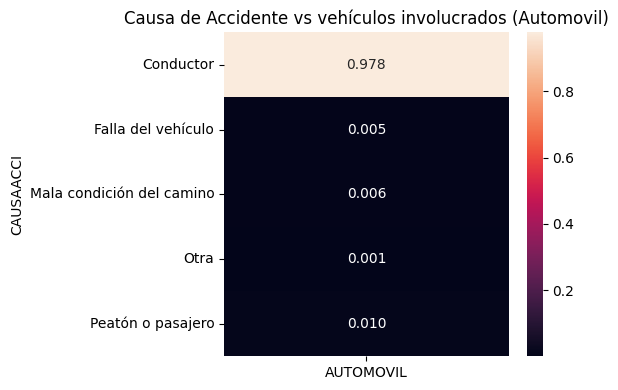

In [22]:
veh_cols = [
    'AUTOMOVIL'
]

# Crear columnas binarias de participación
veh_bin_df = inegi_df.copy()
for col in veh_cols:
    veh_bin_df[col] = (veh_bin_df[col] > 0).astype(int)

# Crosstab individual para cada tipo de vehículo
plt.figure(figsize=(6, 4))
heatmap_data = pd.DataFrame()

for col in veh_cols:
    ct_temp = pd.crosstab(
        veh_bin_df['CAUSAACCI'],
        veh_bin_df[col],
        normalize='columns'
    )[1]  # Solo tomamos la columna que representa la presencia del vehículo
    heatmap_data[col] = ct_temp

sns.heatmap(heatmap_data, annot=True, fmt=".3f")
plt.title("Causa de Accidente vs vehículos involucrados (Automovil)")
plt.tight_layout()
plt.show()

Observaciones:
Podemos ver que la mayor causa de accidentes es por culpa del conductor por  una gran mayoria

#### Tipo (Enfocado a Automovil)

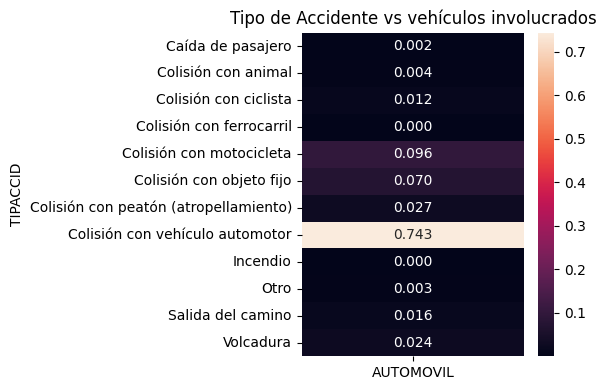

In [23]:
# Crear columnas binarias de participación
veh_bin_df = inegi_df.copy()
for col in veh_cols:
    veh_bin_df[col] = (veh_bin_df[col] > 0).astype(int)

# Crosstab individual para cada tipo de vehículo
plt.figure(figsize=(6, 4))
heatmap_data = pd.DataFrame()

for col in veh_cols:
    ct_temp = pd.crosstab(
        veh_bin_df['TIPACCID'],
        veh_bin_df[col],
        normalize='columns'
    )[1]  # Solo tomamos la columna que representa la presencia del vehículo
    heatmap_data[col] = ct_temp

sns.heatmap(heatmap_data, annot=True, fmt=".3f")
plt.title("Tipo de Accidente vs vehículos involucrados")
plt.tight_layout()
plt.show()


Observaciones:

El mayor tipo de accidente es por **Colision con vehiculo automotor**, seguido por **Colisión con motocicleta** aunque la diferencia es muy grande.

#### Omitiendo Automovil

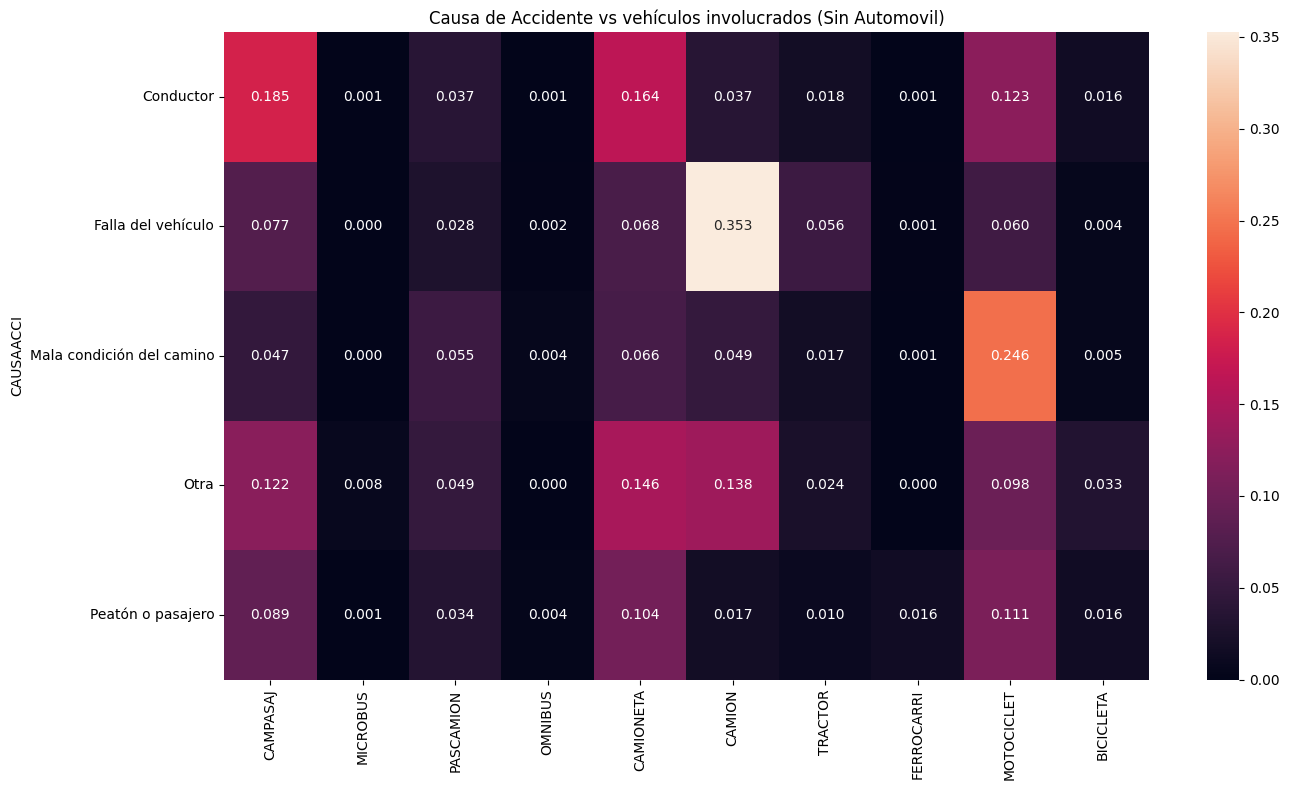

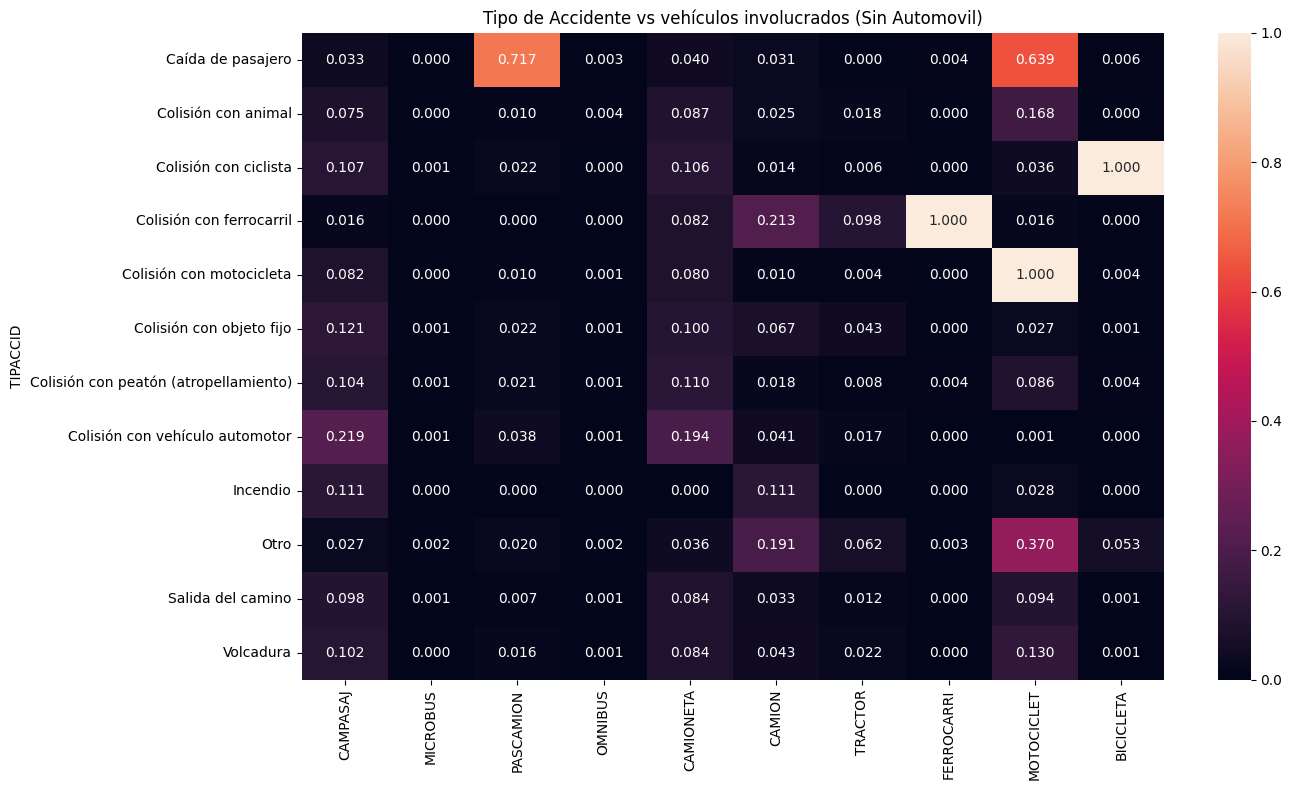

In [24]:
veh_cols = [
    'CAMPASAJ','MICROBUS','PASCAMION','OMNIBUS',
    'CAMIONETA','CAMION','TRACTOR','FERROCARRI','MOTOCICLET','BICICLETA'
]

# Crear columnas binarias de participación
veh_bin_df = inegi_df.copy()
for col in veh_cols:
    veh_bin_df[col] = (veh_bin_df[col] > 0).astype(int)

# Crosstab individual para cada tipo de vehículo
plt.figure(figsize=(14, 8))
heatmap_data = pd.DataFrame()

for col in veh_cols:
    ct_temp = pd.crosstab(
        veh_bin_df['CAUSAACCI'],
        veh_bin_df[col],
        normalize='index'
    )[1]  # Solo tomamos la columna que representa la presencia del vehículo
    heatmap_data[col] = ct_temp

sns.heatmap(heatmap_data, annot=True, fmt=".3f")
plt.title("Causa de Accidente vs vehículos involucrados (Sin Automovil)")
plt.tight_layout()
plt.show()

# Crear columnas binarias de participación
veh_bin_df = inegi_df.copy()
for col in veh_cols:
    veh_bin_df[col] = (veh_bin_df[col] > 0).astype(int)

# Crosstab individual para cada tipo de vehículo
plt.figure(figsize=(14, 8))
heatmap_data = pd.DataFrame()

for col in veh_cols:
    ct_temp = pd.crosstab(
        veh_bin_df['TIPACCID'],
        veh_bin_df[col],
        normalize='index'
    )[1]  # Solo tomamos la columna que representa la presencia del vehículo
    heatmap_data[col] = ct_temp

sns.heatmap(heatmap_data, annot=True, fmt=".3f")
plt.title("Tipo de Accidente vs vehículos involucrados (Sin Automovil)")
plt.tight_layout()
plt.show()


#### Observaciones:
- Causa de Accidentes:
    - Los vehiculos que tienen más accidentes causados por el conductor son:
        - Camion de Pasajeros
        - Camioneta
        - Motocicleta
    - En falla de vehiculo, la mayoria son por:
        - Camion (De carga)
    - Por mala condicion del camino es:
        - Motocicleta
    - Por otro:
        - Camion de Pasajeros
        - Camioneta
        - Motocicleta
        - Camion (De carga)
    - Por culpa del pasajero o peaton:
        - Camion de Pasajeros
        - Camioneta
        - Motocicleta
    - Los vehiculos con la menor cantidad de accidentes son el Mircobus, Omnibus, Ferrocarril y Bicicleta

- Tipo de Accidente:
    - En caida de Pasajero, la mayoria estan dadas por:
        - Camion de Pasajeros
        - Motocicleta
    - En otro solo resalta el vehiculo:
        - Motocicleta
        
    - Hay algunos vehiculos que tienen 1.0 en su valor pero es por que el tipo de accidente involucra el vehiculo en especifico.

## Utilizando reducción de caracteristicas para crear otras visualizaciones

Primero hay que revisar cuantas variables son suficientes para explicar la mayoria del problema

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

# Copia de datos
df = inegi_df.copy()

# 1. Separar columnas categóricas y numéricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

# 2. One-hot encoding
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_data = ohe.fit_transform(df[cat_cols])

ohe_df = pd.DataFrame(
    ohe_data,
    columns=ohe.get_feature_names_out(cat_cols),
    index=df.index
)

# 3. Combinar todo
X_full = pd.concat([
    df[num_cols].reset_index(drop=True),
    ohe_df.reset_index(drop=True)
], axis=1)

print("Matriz final con OHE:", X_full.shape)

# 4. Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)


Numéricas: ['ID_MUNICIPIO', 'ANIO', 'MES', 'ID_HORA', 'ID_MINUTO', 'ID_DIA', 'AUTOMOVIL', 'CAMPASAJ', 'MICROBUS', 'PASCAMION', 'OMNIBUS', 'CAMIONETA', 'CAMION', 'TRACTOR', 'FERROCARRI', 'MOTOCICLET', 'BICICLETA', 'OTROVEHIC', 'ID_EDAD']
Categóricas: ['DIASEMANA', 'URBANA', 'SUBURBANA', 'TIPACCID', 'CAUSAACCI', 'CAPAROD', 'SEXO', 'ALIENTO', 'CINTURON', 'CLASACC']
Matriz final con OHE: (142641, 64)


A las variables categoricas es necesario aplicarles One Hot Encoding para poderlas utilizar


Componentes necesarios por umbral de varianza explicada:
  80% -> 33 componentes
  90% -> 40 componentes
  95% -> 44 componentes
  99% -> 49 componentes


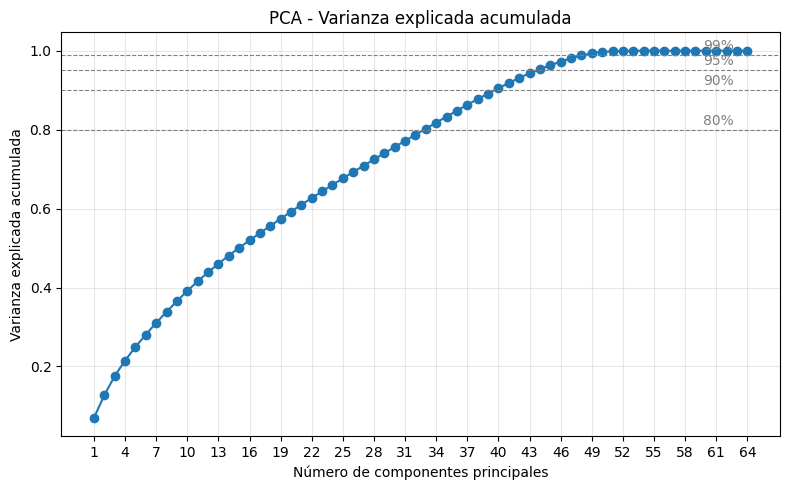

In [35]:
from sklearn.decomposition import PCA

# PCA para determinar cuántas variables conservar (explicabilidad)

# Ajustar PCA completo
pca = PCA()
pca.fit(X_scaled)
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

# Umbrales comunes y número de componentes necesarios
thresholds = [0.80, 0.90, 0.95, 0.99]
needed = {t: int(np.searchsorted(cum_explained, t) + 1) for t in thresholds}

print("\nComponentes necesarios por umbral de varianza explicada:")
for t, n in needed.items():
    print(f"  {int(t*100)}% -> {n} componentes")

# Tabla con varianza explicada acumulada por componente
var_df = pd.DataFrame({
    'component': np.arange(1, len(explained)+1),
    'explained_variance_ratio': explained,
    'cumulative_explained': cum_explained
})

# Gráfica Scree / Varianza acumulada
plt.figure(figsize=(8,5))
plt.plot(var_df['component'], var_df['cumulative_explained'], marker='o')
for t in thresholds:
    plt.axhline(y=t, color='gray', linestyle='--', linewidth=0.8)
    plt.text(len(explained)*0.98, t+0.005, f"{int(t*100)}%", ha='right', va='bottom', color='gray')
plt.xticks(np.arange(1, len(explained)+1, max(1, len(explained)//20)))
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA - Varianza explicada acumulada')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Parece que la mejor cantidad de componentes se encuentra entre 40 y 44 para mantener la explicabilidad de 90% - 95%.

In [40]:
# === 5. Aplicar PCA con 44 componentes ===
pca = PCA(n_components=40, random_state=42)
X_pca_40 = pca.fit_transform(X_scaled)

print("Shape original:", X_scaled.shape)
print("Shape reducido:", X_pca_40.shape)


Shape original: (142641, 64)
Shape reducido: (142641, 40)


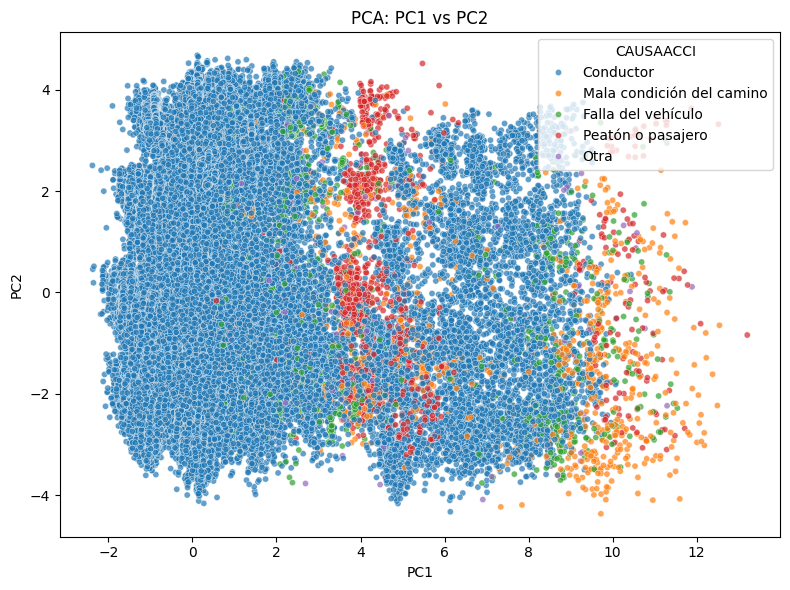

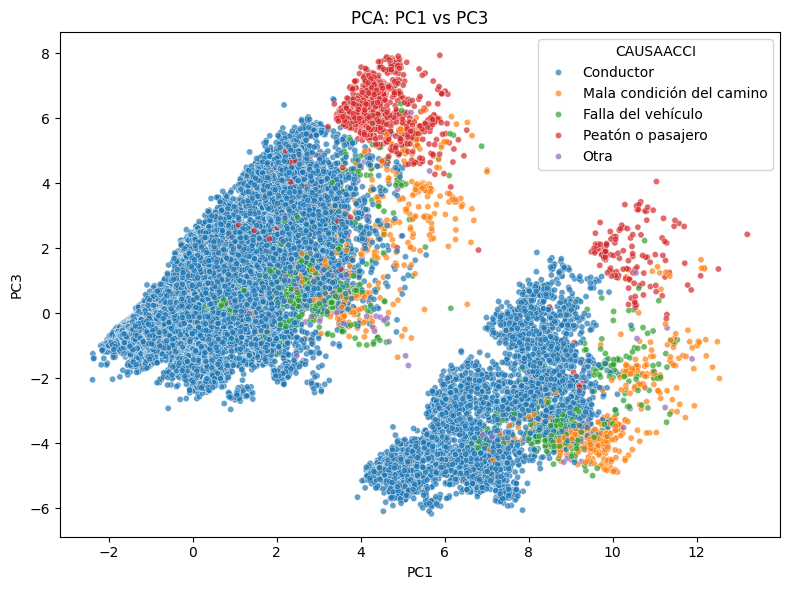

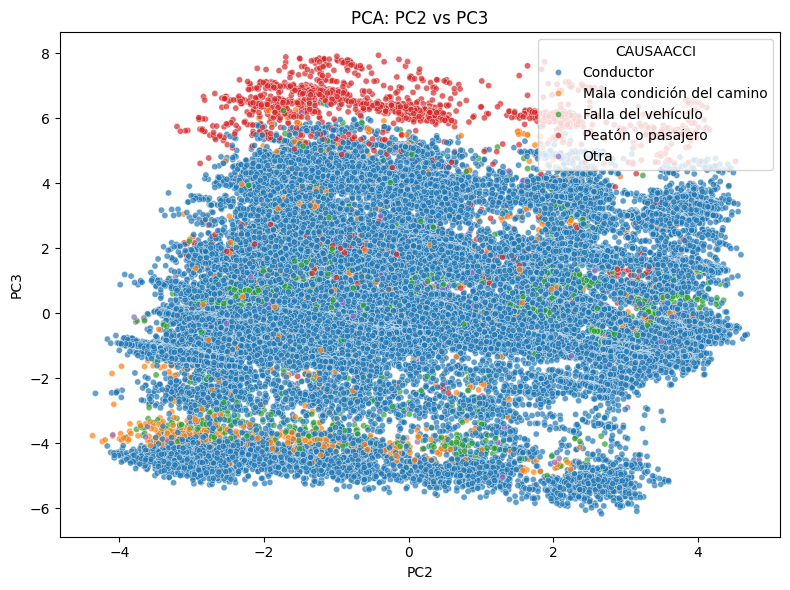

In [48]:
# Crear dataframe con los componentes
pca_df = pd.DataFrame(
    X_pca_40, 
    columns=[f"PC{i+1}" for i in range(X_pca_40.shape[1])]
)

# Añadir la variable categórica para colorear
pca_df['CAUSAACCI'] = inegi_df['CAUSAACCI'].values

# 1. PC1 vs PC2
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='CAUSAACCI',
    s=20,
    alpha=0.7
)
plt.title("PCA: PC1 vs PC2")
plt.tight_layout()
plt.show()

# 2. PC1 vs PC3
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC3',
    hue='CAUSAACCI',
    s=20,
    alpha=0.7
)
plt.title("PCA: PC1 vs PC3")
plt.tight_layout()
plt.show()

# 3. PC2 vs PC3
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC2',
    y='PC3',
    hue='CAUSAACCI',
    s=20,
    alpha=0.7
)
plt.title("PCA: PC2 vs PC3")
plt.tight_layout()
plt.show()


Se puede observar que hay una segmentación clara entre los accidentes causados por culpa del conductor, por culpa de un peaton o pasajero y masomenos por mala condicion del camino

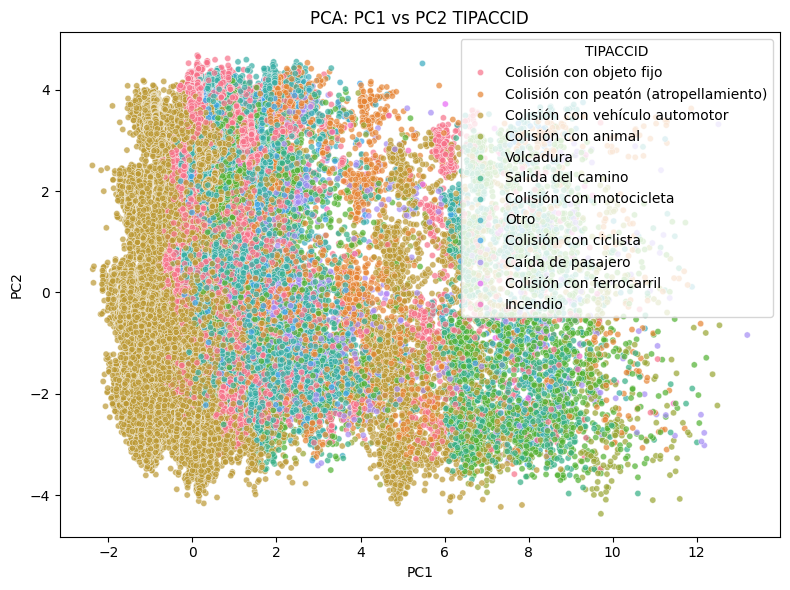

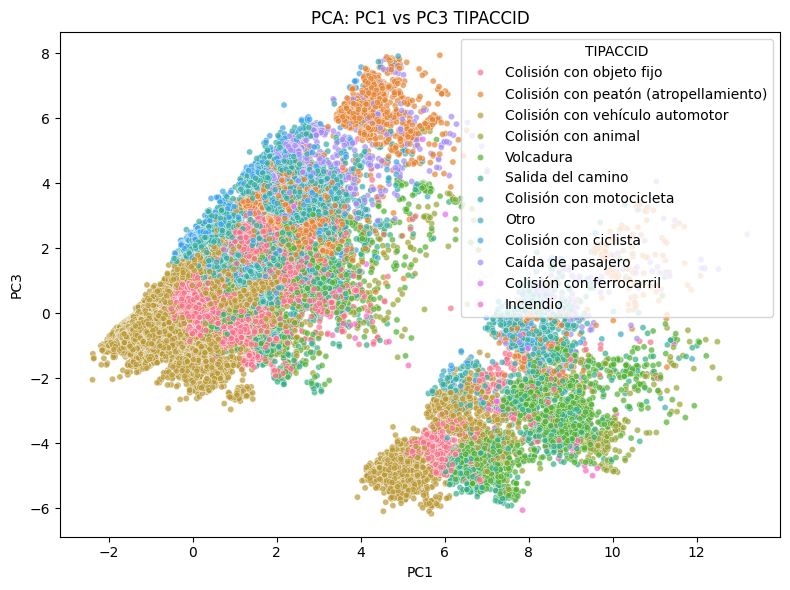

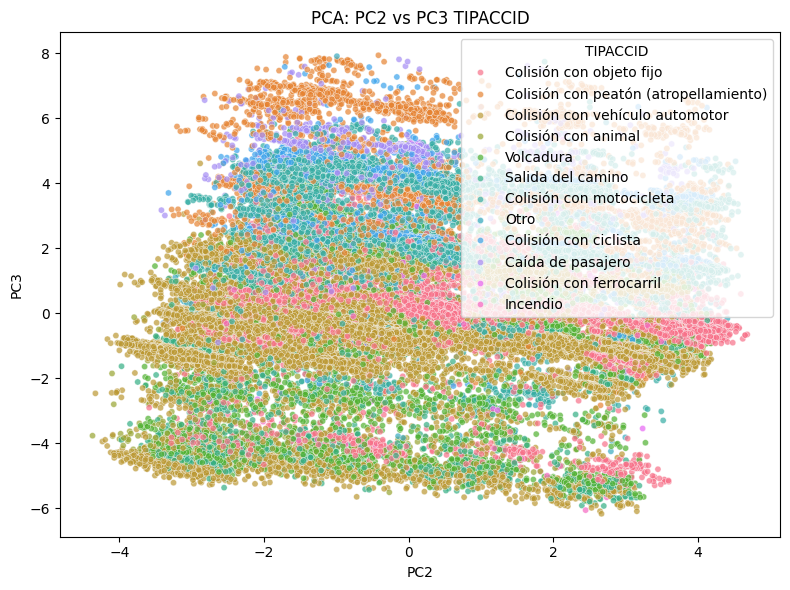

In [53]:
# Crear dataframe con los componentes
pca_df = pd.DataFrame(
    X_pca_40, 
    columns=[f"PC{i+1}" for i in range(X_pca_40.shape[1])]
)

# Añadir la variable categórica para colorear
pca_df['TIPACCID'] = inegi_df['TIPACCID'].values

# 1. PC1 vs PC2
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='TIPACCID',
    s=20,
    alpha=0.7
)
plt.title("PCA: PC1 vs PC2 TIPACCID")
plt.tight_layout()
plt.show()

# 2. PC1 vs PC3
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC3',
    hue='TIPACCID',
    s=20,
    alpha=0.7
)
plt.title("PCA: PC1 vs PC3 TIPACCID")
plt.tight_layout()
plt.show()

# 3. PC2 vs PC3
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC2',
    y='PC3',
    hue='TIPACCID',
    s=20,
    alpha=0.7
)
plt.title("PCA: PC2 vs PC3 TIPACCID")
plt.tight_layout()
plt.show()


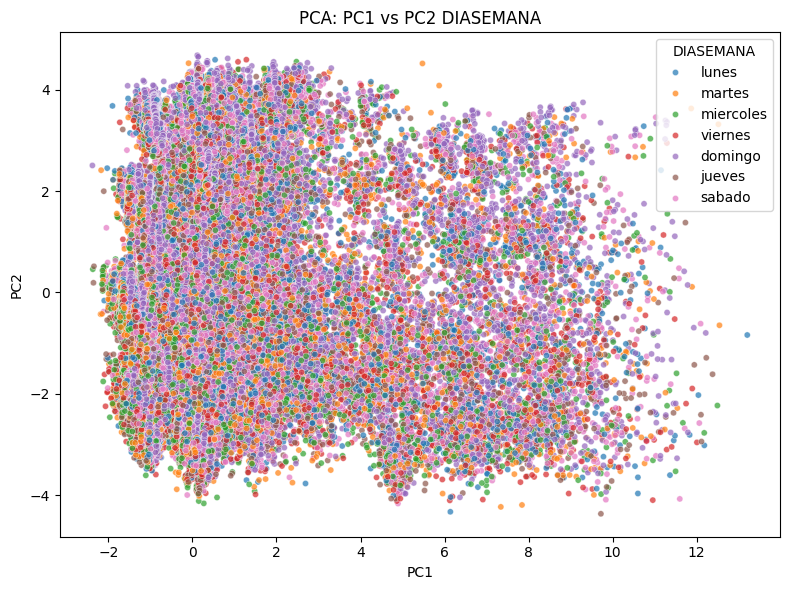

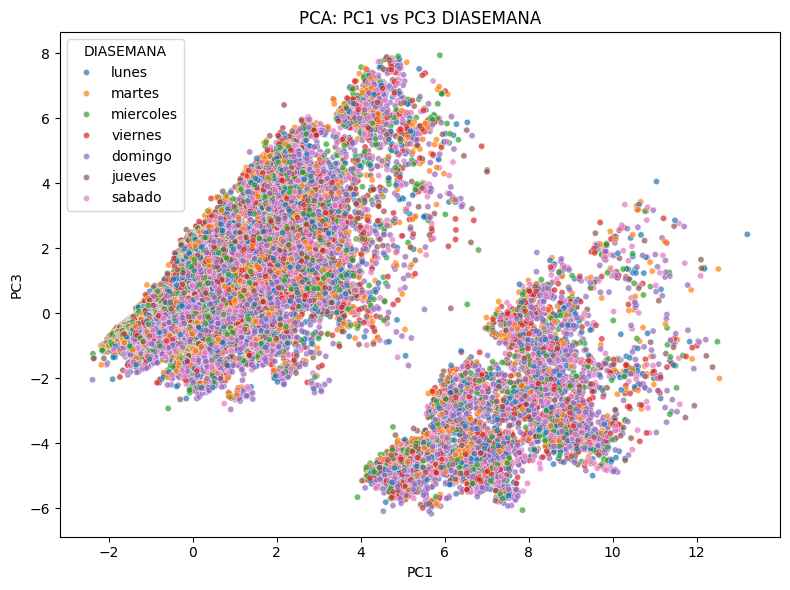

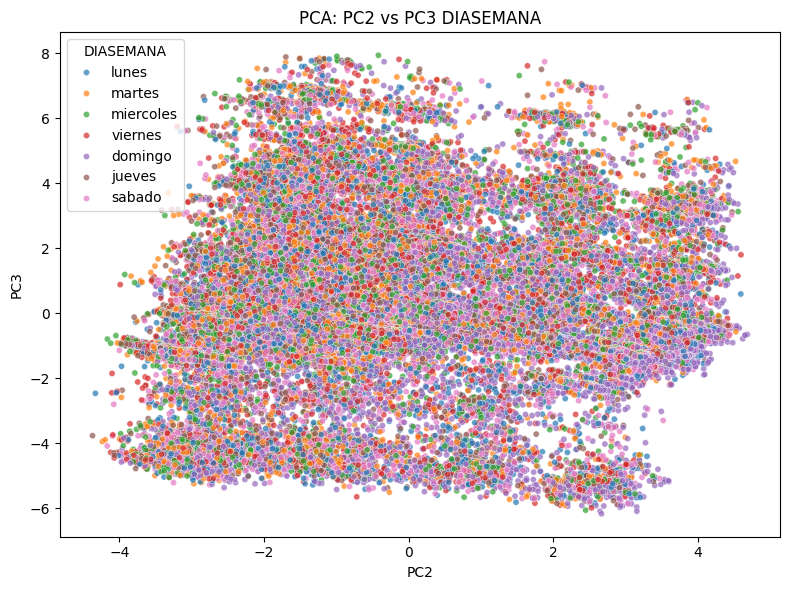

In [54]:
# Crear dataframe con los componentes
pca_df = pd.DataFrame(
    X_pca_40, 
    columns=[f"PC{i+1}" for i in range(X_pca_40.shape[1])]
)

# Añadir la variable categórica para colorear
pca_df['DIASEMANA'] = inegi_df['DIASEMANA'].values

# 1. PC1 vs PC2
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='DIASEMANA',
    s=20,
    alpha=0.7
)
plt.title("PCA: PC1 vs PC2 DIASEMANA")
plt.tight_layout()
plt.show()

# 2. PC1 vs PC3
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC3',
    hue='DIASEMANA',
    s=20,
    alpha=0.7
)
plt.title("PCA: PC1 vs PC3 DIASEMANA")
plt.tight_layout()
plt.show()

# 3. PC2 vs PC3
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC2',
    y='PC3',
    hue='DIASEMANA',
    s=20,
    alpha=0.7
)
plt.title("PCA: PC2 vs PC3 DIASEMANA")
plt.tight_layout()
plt.show()


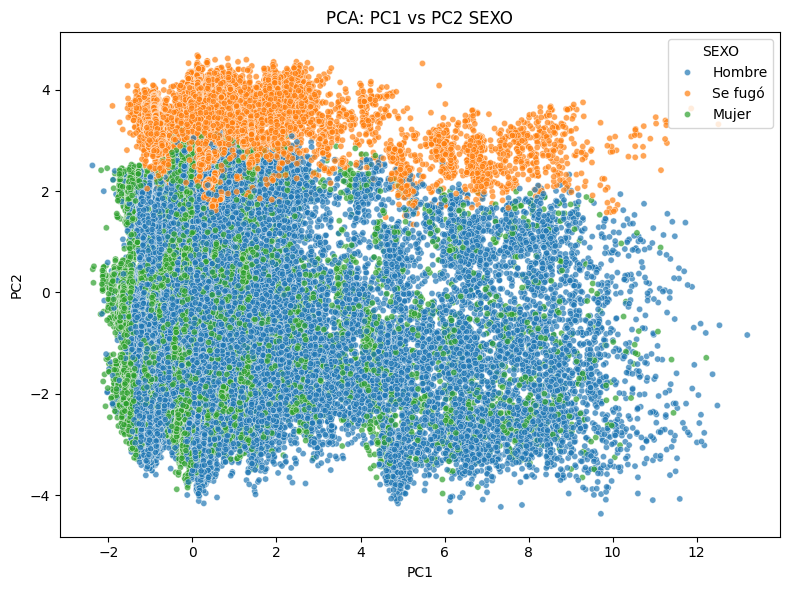

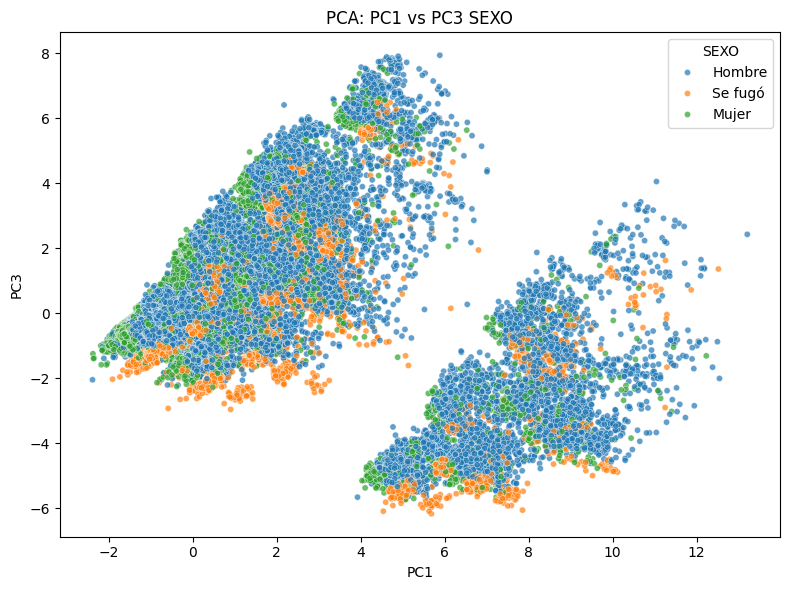

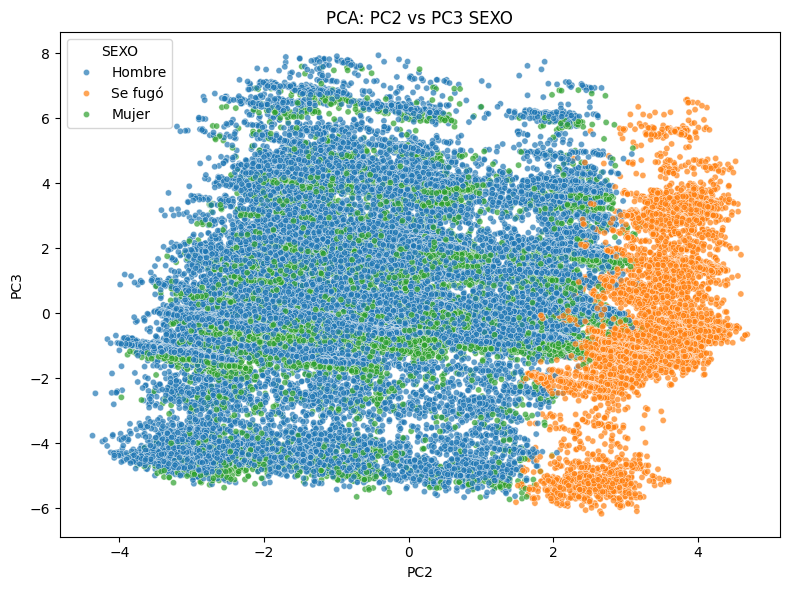

In [55]:
# Crear dataframe con los componentes
pca_df = pd.DataFrame(
    X_pca_40, 
    columns=[f"PC{i+1}" for i in range(X_pca_40.shape[1])]
)

# Añadir la variable categórica para colorear
pca_df['SEXO'] = inegi_df['SEXO'].values

# 1. PC1 vs PC2
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='SEXO',
    s=20,
    alpha=0.7
)
plt.title("PCA: PC1 vs PC2 SEXO")
plt.tight_layout()
plt.show()

# 2. PC1 vs PC3
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC3',
    hue='SEXO',
    s=20,
    alpha=0.7
)
plt.title("PCA: PC1 vs PC3 SEXO")
plt.tight_layout()
plt.show()

# 3. PC2 vs PC3
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC2',
    y='PC3',
    hue='SEXO',
    s=20,
    alpha=0.7
)
plt.title("PCA: PC2 vs PC3 SEXO")
plt.tight_layout()
plt.show()


Parece que si se separan los componentes, asi que habra que observar los __Loadings__

In [57]:
# Loadings de PCA (pesos de cada variable en cada componente)
loadings = pd.DataFrame(
    pca.components_.T,          # transponemos para que cada fila sea una variable
    index=X_full.columns,        # nombres de tus columnas originales
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

# Mostrar los 10 pesos más fuertes (positivos o negativos) para PC1, PC2
for pc in ['PC1', 'PC2', 'PC3']:
    print(f"\nTop loadings en {pc}:")
    display(
        loadings[pc]
        .sort_values(key=lambda x: x.abs(), ascending=False)
        .head(10)
        .to_frame()
    )



Top loadings en PC1:


,PC1
URBANA_Sin accidente en esta zona,0.377572
SUBURBANA_Sin accidente en esta zona,-0.377572
URBANA_Accidente en intersección,-0.317802
TIPACCID_Colisión con vehículo automotor,-0.285264
SUBURBANA_Accidente en carretera estatal,0.255159
CLASACC_Sólo daños,-0.245346
SUBURBANA_Accidente en camino rural,0.240034
CLASACC_No fatal,0.221626
CAUSAACCI_Conductor,-0.186584
TIPACCID_Volcadura,0.176919



Top loadings en PC2:


,PC2
ALIENTO_Se ignora,0.442805
ALIENTO_No,-0.433705
CINTURON_Se ignora,0.383925
CINTURON_Sí,-0.351574
SEXO_Se fugó,0.332773
ID_EDAD,-0.241648
ID_MUNICIPIO,-0.183535
SEXO_Hombre,-0.171615
CAMPASAJ,-0.129676
TIPACCID_Colisión con vehículo automotor,-0.108564



Top loadings en PC3:


,PC3
CLASACC_No fatal,0.339392
CLASACC_Sólo daños,-0.333074
MOTOCICLET,0.301795
SUBURBANA_Sin accidente en esta zona,0.279819
URBANA_Sin accidente en esta zona,-0.279819
TIPACCID_Colisión con vehículo automotor,-0.268459
TIPACCID_Colisión con motocicleta,0.267721
TIPACCID_Colisión con peatón (atropellamiento),0.236069
URBANA_Accidente en intersección,0.234425
CAUSAACCI_Peatón o pasajero,0.197979


Ahora podemos buscar relaciones entre nuestras componentes utilizando el resultado de PCA para optimizar el proceso

d:\MasterHDXD\Escuela\Maestria\Ingenieria_de_caracteristicas\Proyecto\proyecto_ing_datos\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


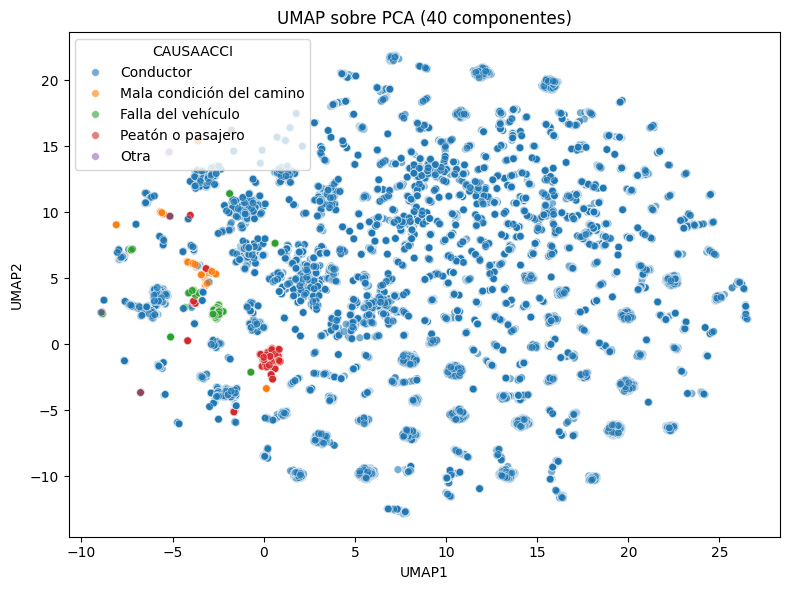

In [41]:
import umap.umap_ as umap

umap_model = umap.UMAP(
    n_neighbors=20,
    min_dist=0.1,
    metric='cosine',         # MUY bueno cuando vienes de PCA
    random_state=42
)

X_umap = umap_model.fit_transform(X_pca_40)

umap_df = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2'], index=df.index)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=umap_df.join(df['CAUSAACCI']),
    x='UMAP1',
    y='UMAP2',
    hue='CAUSAACCI',
    alpha=0.6,
    s=30
)
plt.title("UMAP sobre PCA (40 componentes)")
plt.tight_layout()
plt.show()


No se alcanzan a distingir clusters, asi que vamos a probar otras tecnicas

**NOTA:** utilice OPTICS que realiza algo como HDBSCAN pero el resultado me dio una grafica que no decia nada y tomaba mucho espacio, asi que elimine esa seccion